Importacion de paquetes y apertura de bases de datos

In [36]:
from google.colab import drive

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# COMPARAR OLS vs BAGGING PARA TREN Y SUBTE
print("\n============================================")
print("COMPARACIÓN OLS vs BAGGING (TREN y SUBTE)")
print("============================================")

import statsmodels.api as sm

# Se asume que ya definiste:
#   - categorical_features
#   - X_train_tren, X_test_tren, y_train_tren, y_test_tren
#   - X_train_subte, X_test_subte, y_train_subte, y_test_subte

for tipo, X_train, X_test, y_train, y_test in [
    ("TREN",  X_train_tren,  X_test_tren,  y_train_tren,  y_test_tren),
    ("SUBTE", X_train_subte, X_test_subte, y_train_subte, y_test_subte)
]:
    print(f"\n\n========== {tipo} ==========")

    # OneHot para OLS
    X_train_dummies = pd.get_dummies(
        X_train,
        columns=categorical_features,
        drop_first=True
    )

    X_test_dummies = pd.get_dummies(
        X_test,
        columns=categorical_features,
        drop_first=True
    )

    # Forzar a float para y_train_ols y y_test_ols
    y_train_ols = y_train.astype(float)
    y_test_ols  = y_test.astype(float)

    # Armamos un solo df y dropeamos filas con NaN en train
    df_ols_train = pd.concat(
        [y_train_ols.rename("CANTIDAD"), X_train_dummies],
        axis=1
    ).dropna()

    y_train_ols = df_ols_train["CANTIDAD"]
    X_train_ols_no_const = df_ols_train.drop(columns=["CANTIDAD"])

    # Alinear columnas de X_test_dummies con las de X_train_ols_no_const
    X_test_ols_no_const = X_test_dummies.reindex(
        columns=X_train_ols_no_const.columns,
        fill_value=0
    )

    # Forzar a float para los DataFrames finales
    X_train_ols_no_const = X_train_ols_no_const.astype(float)
    X_test_ols_no_const  = X_test_ols_no_const.astype(float)

    # Agregar constante a ambos sets
    X_train_ols = sm.add_constant(X_train_ols_no_const)
    X_test_ols  = sm.add_constant(X_test_ols_no_const)

    # Ajustar OLS
    ols_model = sm.OLS(y_train_ols, X_train_ols).fit()

    print("\n--- Resumen OLS ---")
    print(ols_model.summary())

    # Predicción
    y_pred_ols = ols_model.predict(X_test_ols)

    # CORRECCIÓN: filtrar cualquier NaN antes de calcular métricas
    mask_valid = (~y_test_ols.isna()) & (~pd.isna(y_pred_ols))
    y_test_valid = y_test_ols[mask_valid]
    y_pred_valid = y_pred_ols[mask_valid]

    # Métricas OLS
    mae_ols  = mean_absolute_error(y_test_valid, y_pred_valid)
    rmse_ols = np.sqrt(mean_squared_error(y_test_valid, y_pred_valid))
    r2_ols   = r2_score(y_test_valid, y_pred_valid)

    print(f"\n=== MÉTRICAS OLS ({tipo}) ===")
    print(f"MAE : {mae_ols:,.2f}")
    print(f"RMSE: {rmse_ols:,.2f}")
    print(f"R²  : {r2_ols:,.3f}")




COMPARACIÓN OLS vs BAGGING (solo TREN)

--- Resumen OLS ---
                            OLS Regression Results                            
Dep. Variable:               CANTIDAD   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     4813.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        01:49:03   Log-Likelihood:            -1.4179e+05
No. Observations:               12129   AIC:                         2.836e+05
Df Residuals:                   12102   BIC:                         2.838e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

In [ ]:
# RUTAS y BASES
drive.mount('/content/drive')
base_25 = pd.read_csv("/content/drive/MyDrive/Programacion/dat-ab-usos-2025.csv")
base_24 = pd.read_csv("/content/drive/MyDrive/Programacion/dat-ab-usos-2024.csv")
base_23 = pd.read_csv("/content/drive/MyDrive/Programacion/dat-ab-usos-2023.csv")

print("Base 2023:", base_23.shape)
print("Base 2024:", base_24.shape)
print("Base 2025:", base_25.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base 2023: (472291, 10)
Base 2024: (504676, 10)
Base 2025: (501048, 10)


# Exploración de base general

Union de las bases 2023 y 2024 que utilizaremos para entrenar y generacion de variables estructurales. Con eso, predecimos 2025.

In [ ]:
# Filtramos AMBA
base_23 = base_23[base_23["AMBA"] == "SI"].copy()
base_24 = base_24[base_24["AMBA"] == "SI"].copy()
base_25 = base_25[base_25["AMBA"] == "SI"].copy()

# Unimos
amba = pd.concat([base_23, base_24, base_25], ignore_index=True)
# Asegurar formato fecha
amba["DIA_TRANSPORTE"] = pd.to_datetime(amba["DIA_TRANSPORTE"])

print("AMBA combinado:", amba.shape)
amba.info()

AMBA combinado: (438172, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438172 entries, 0 to 438171
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   DIA_TRANSPORTE   438172 non-null  datetime64[ns]
 1   NOMBRE_EMPRESA   438172 non-null  object        
 2   LINEA            438172 non-null  object        
 3   AMBA             438172 non-null  object        
 4   TIPO_TRANSPORTE  438172 non-null  object        
 5   JURISDICCION     430604 non-null  object        
 6   PROVINCIA        430582 non-null  object        
 7   MUNICIPIO        430582 non-null  object        
 8   CANTIDAD         438172 non-null  int64         
 9   DATO_PRELIMINAR  438172 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 33.4+ MB


In [ ]:
# VARIABLES TEMPORALES y filtro por TREN
# Aseguramos tipo datetime
amba["DIA_TRANSPORTE"] = pd.to_datetime(amba["DIA_TRANSPORTE"])
# Columna fecha base
amba["fecha"] = amba["DIA_TRANSPORTE"]

# Variables temporales a nivel general (todas las observaciones)
amba["dia_semana"] = amba["fecha"].dt.weekday          # 0 = lunes, 6 = domingo
amba["mes"]        = amba["fecha"].dt.month            # 1–12
amba["anio"]       = amba["fecha"].dt.year
amba["clases"]     = amba["fecha"].dt.month.between(3, 12).astype(int)  # marzo–diciembre = 1

print("Columnas temporales agregadas en amba:", ["fecha", "dia_semana", "mes", "anio", "clases"])

# SUBCONJUNTO: SOLO TREN
df_tren = amba[amba["TIPO_TRANSPORTE"] == "TREN"].copy()

# Ya tenemos 'fecha', 'dia_semana', 'mes', 'anio' desde amba
# Solo agregamos lo que es específico para el modelo de TREN
df_tren = df_tren.sort_values(["LINEA", "fecha"])

# Día del mes y fin de semana (derivados de la fecha / dia_semana)
df_tren["dia_mes"]   = df_tren["fecha"].dt.day
df_tren["fin_semana"] = (df_tren["dia_semana"] >= 5).astype(int)

# Lags por línea
df_tren["lag_1"] = df_tren.groupby("LINEA")["CANTIDAD"].shift(1)
df_tren["lag_7"] = df_tren.groupby("LINEA")["CANTIDAD"].shift(7)

# Medias móviles por línea
df_tren["media_7"] = df_tren.groupby("LINEA")["CANTIDAD"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df_tren["media_30"] = df_tren.groupby("LINEA")["CANTIDAD"].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
)

# Eliminamos solo filas sin lag_1
df_tren = df_tren.dropna(subset=["lag_1"]).copy()

print("Datos finales TREN (con features):", df_tren.shape)
print("Rango de fechas TREN:", df_tren["fecha"].min().date(), "→", df_tren["fecha"].max().date())


Columnas temporales agregadas en amba: ['fecha', 'dia_semana', 'mes', 'anio', 'clases']
Datos finales TREN (con features): (17312, 21)
Rango de fechas TREN: 2023-01-02 → 2025-12-05


In [23]:
# SOLO SUBTE
df_subte = amba[amba["TIPO_TRANSPORTE"] == "SUBTE"].copy()
df_subte = df_subte.sort_values(["LINEA", "fecha"])

# Día del mes y fin de semana
df_subte["dia_mes"]    = df_subte["fecha"].dt.day
df_subte["fin_semana"] = (df_subte["dia_semana"] >= 5).astype(int)

# Lags por línea
df_subte["lag_1"] = df_subte.groupby("LINEA")["CANTIDAD"].shift(1)
df_subte["lag_7"] = df_subte.groupby("LINEA")["CANTIDAD"].shift(7)

# Medias móviles por línea
df_subte["media_7"] = df_subte.groupby("LINEA")["CANTIDAD"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df_subte["media_30"] = df_subte.groupby("LINEA")["CANTIDAD"].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
)

# Eliminamos solo filas sin lag_1
df_subte = df_subte.dropna(subset=["lag_1"]).copy()

print("Datos finales SUBTE (con features):", df_subte.shape)
print("Rango de fechas SUBTE:", df_subte["fecha"].min().date(), "→", df_subte["fecha"].max().date())

Datos finales SUBTE (con features): (7559, 21)
Rango de fechas SUBTE: 2023-01-02 → 2025-12-05


Analisis exploratorio y descriptivo



Observaciones TREN: 17312

=== Descriptivos de CANTIDAD (TREN) ===


,CANTIDAD
count,17312.000000
mean,53844.888690
std,96431.975516
min,-417.000000
25%,157.000000
50%,4502.000000
75%,65195.250000
max,542616.000000



=== Deciles de CANTIDAD (TREN) ===


,CANTIDAD
0.0,-417.0
0.1,37.0
0.2,109.0
0.3,223.0
0.4,922.4
0.5,4502.0
0.6,33772.8
0.7,56000.7
0.8,75749.6
0.9,124323.6


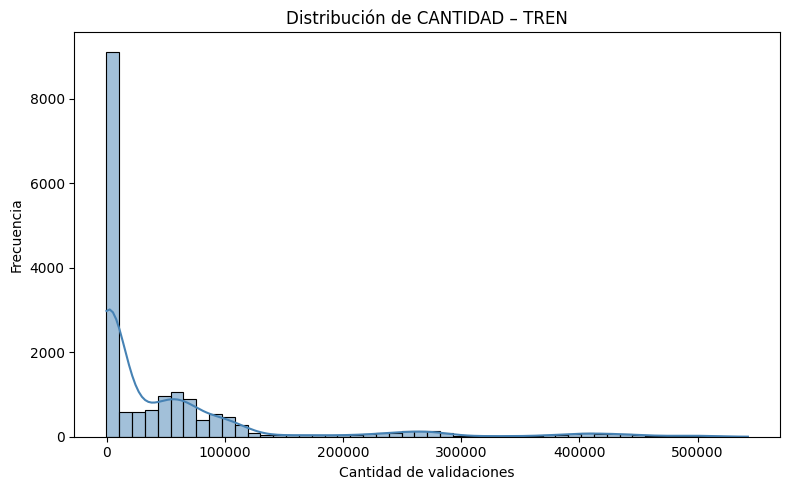

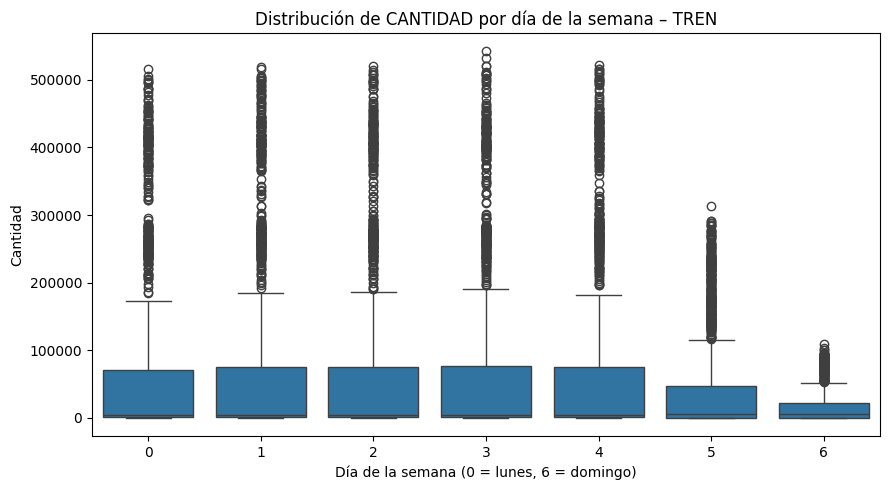

In [ ]:
print("Observaciones TREN:", df_tren.shape[0])

# --------------------------------------
# DESCRIPTIVOS TREN
# --------------------------------------
print("\n=== Descriptivos de CANTIDAD (TREN) ===")
display(df_tren["CANTIDAD"].describe())

print("\n=== Deciles de CANTIDAD (TREN) ===")
display(df_tren["CANTIDAD"].quantile([i/10 for i in range(11)]))

# --------------------------------------
# HISTOGRAMA
# --------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_tren,
    x="CANTIDAD",
    bins=50,
    kde=True,
    color="steelblue"
)
plt.title("Distribución de CANTIDAD – TREN")
plt.xlabel("Cantidad de validaciones")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# --------------------------------------
# BOXPLOT POR DÍA DE LA SEMANA
# --------------------------------------
# (asume que ya creaste df_tren["dia_semana"])
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_tren,
    x="dia_semana",
    y="CANTIDAD"
)
plt.title("Distribución de CANTIDAD por día de la semana – TREN")
plt.xlabel("Día de la semana (0 = lunes, 6 = domingo)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

Observaciones SUBTE: 7559

=== Descriptivos de CANTIDAD (SUBTE) ===


,CANTIDAD
count,7559.000000
mean,76145.582484
std,59660.794772
min,1.000000
25%,26042.000000
50%,69245.000000
75%,112145.500000
max,259776.000000



=== Deciles de CANTIDAD (SUBTE) ===


,CANTIDAD
0.0,1.0
0.1,1428.4
0.2,18143.8
0.3,34979.2
0.4,52401.6
0.5,69245.0
0.6,84136.0
0.7,100940.0
0.8,127485.2
0.9,169108.2


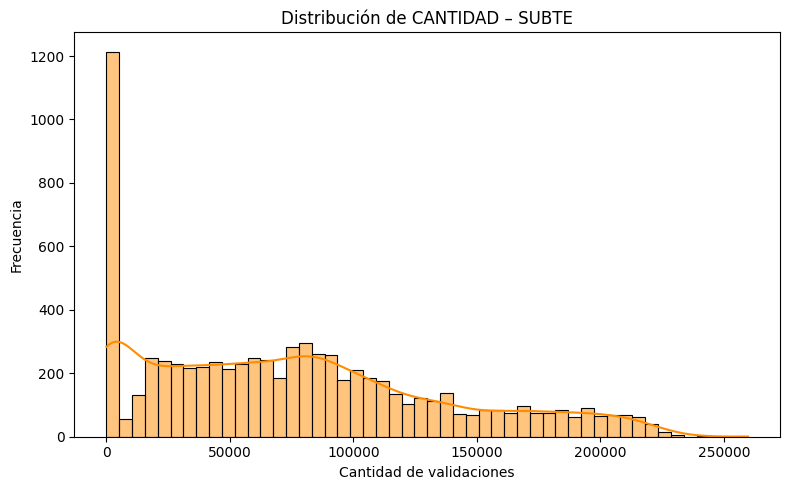

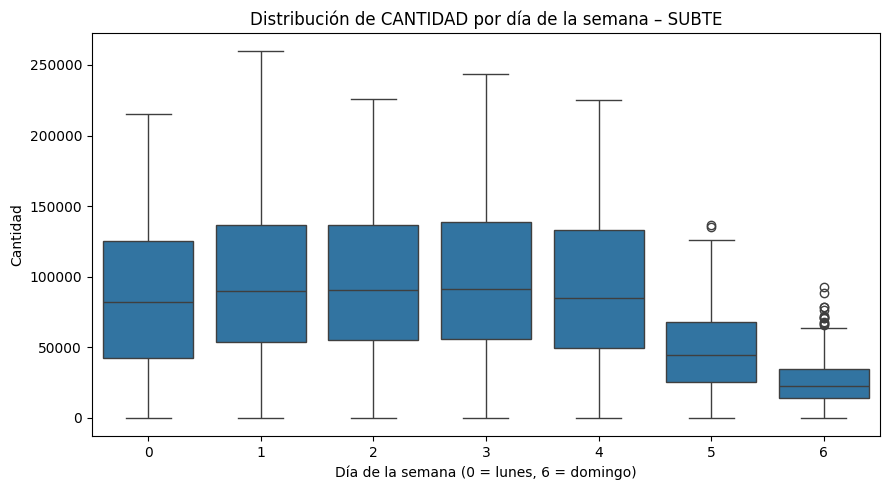

In [24]:
# DESCRIPTIVOS – SUBTE
print("Observaciones SUBTE:", df_subte.shape[0])

# --------------------------------------
# DESCRIPTIVOS
# --------------------------------------
print("\n=== Descriptivos de CANTIDAD (SUBTE) ===")
display(df_subte["CANTIDAD"].describe())

print("\n=== Deciles de CANTIDAD (SUBTE) ===")
display(df_subte["CANTIDAD"].quantile([i/10 for i in range(11)]))

# --------------------------------------
# HISTOGRAMA
# --------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_subte,
    x="CANTIDAD",
    bins=50,
    kde=True,
    color="darkorange"
)
plt.title("Distribución de CANTIDAD – SUBTE")
plt.xlabel("Cantidad de validaciones")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# --------------------------------------
# BOXPLOT POR DÍA DE LA SEMANA
# --------------------------------------
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_subte,
    x="dia_semana",
    y="CANTIDAD"
)
plt.title("Distribución de CANTIDAD por día de la semana – SUBTE")
plt.xlabel("Día de la semana (0 = lunes, 6 = domingo)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

In [ ]:
# DESCRIPTIVOS DE USO POR LÍNEA (TREN)
desc_por_linea = (
    df_tren
    .groupby("LINEA")["CANTIDAD"]
    .agg(
        media="mean",
        mediana="median",
        desvio="std",
        minimo="min",
        maximo="max",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
    .sort_values("media", ascending=False)
)

display(desc_por_linea.round(0))

,media,mediana,desvio,minimo,maximo,p25,p75
LINEA,,,,,,,
FFCC ROCA,324335.0,389780.0,143307.0,7,542616,218951.0,428670.0
FFCC SAR,196745.0,239059.0,89772.0,5,312845,143590.0,267122.0
FFCC_SANM,81473.0,93838.0,34256.0,22,128672,62391.0,107696.0
FFCC_BELGRANO_NORTE,76328.0,87495.0,28310.0,1,126209,54326.0,97602.0
FCC MITRE_TIGRE,55423.0,56648.0,23023.0,-1,123243,40034.0,71660.0
FFCC URQUIZA,50215.0,60478.0,21763.0,14,84251,30361.0,67884.0
FFCC_SUAREZ,43485.0,52980.0,22086.0,0,77905,20294.0,61531.0
FFCC_BELG_SUR,38952.0,44475.0,15954.0,-11,73310,34812.0,48731.0
FFCC_TREN_COSTA,3668.0,3574.0,1036.0,38,7003,3035.0,4276.0


In [25]:
# DESCRIPTIVOS DE USO POR LÍNEA (SUBTE)
desc_por_linea_subte = (
    df_subte
    .groupby("LINEA")["CANTIDAD"]
    .agg(
        media="mean",
        mediana="median",
        desvio="std",
        minimo="min",
        maximo="max",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
    .sort_values("media", ascending=False)
)

display(desc_por_linea_subte.round(0))

,media,mediana,desvio,minimo,maximo,p25,p75
LINEA,,,,,,,
LINEA_B,131541.0,129166.0,59528.0,1,259776,82211.0,181009.0
LINEA SUBTE D,109670.0,103680.0,59869.0,1,232747,59229.0,154806.0
LINEA_A,109532.0,105614.0,54796.0,6,222073,65916.0,157750.0
LINEA SUBTE C,82934.0,86956.0,35802.0,1,188687,50998.0,110842.0
LINEA SUBTE H,57011.0,61314.0,26096.0,4,110570,34560.0,78376.0
LINEA SUBTE E,49914.0,51514.0,25502.0,6,120366,25250.0,73462.0
LIN_VERDE_D,4350.0,5637.0,2008.0,683,6167,2338.0,5921.0
LIN_PREMETRO,1343.0,1318.0,653.0,1,4704,943.0,1664.0
LIN_AMARILLA_C,397.0,455.0,136.0,104,558,310.0,491.0


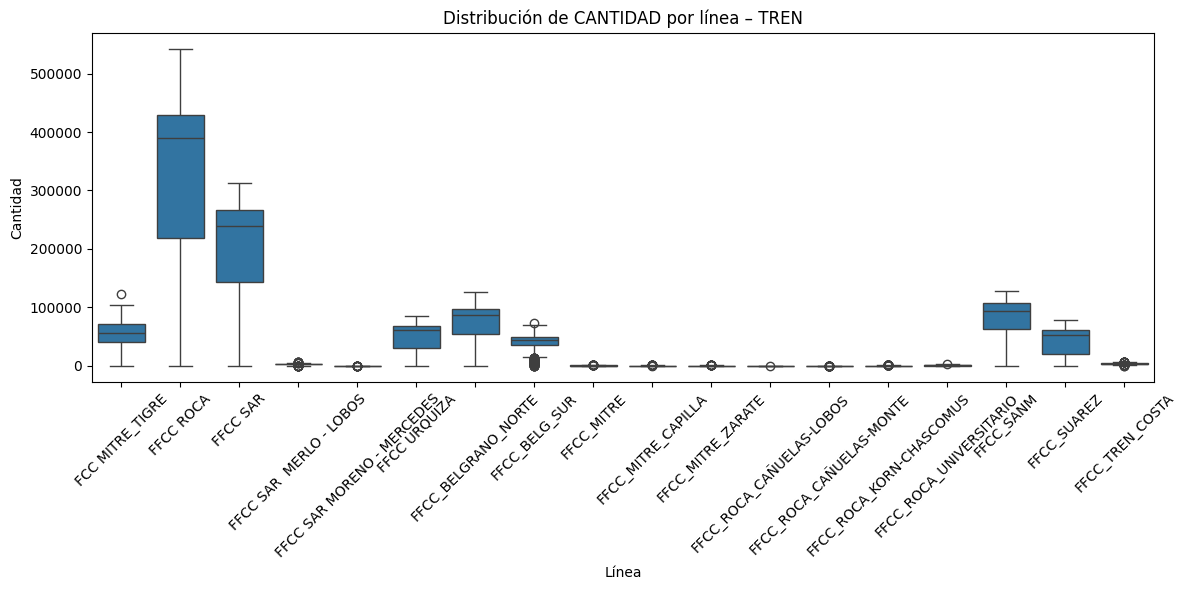

In [ ]:
#Boxplot por linea - Tren

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_tren,
    x="LINEA",
    y="CANTIDAD"
)
plt.title("Distribución de CANTIDAD por línea – TREN")
plt.xlabel("Línea")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

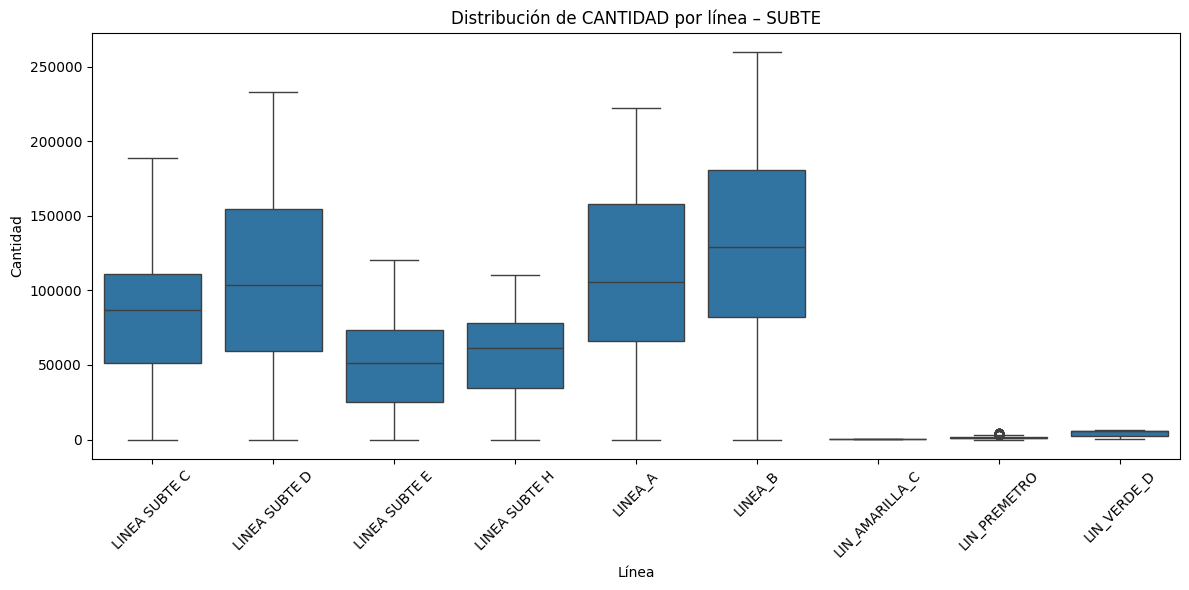

In [26]:
# BOXPLOT POR LÍNEA – SUBTE
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_subte,
    x="LINEA",
    y="CANTIDAD"
)
plt.title("Distribución de CANTIDAD por línea – SUBTE")
plt.xlabel("Línea")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# DESCRIPTIVOS POR DÍA DE LA SEMANA – TREN vs SUBTE
def descriptivos_por_dia(df, nombre):
    stats = (
        df
        .groupby("dia_semana")["CANTIDAD"]
        .agg(
            media="mean",
            mediana="median",
            desvio="std",
            observaciones="count"
        )
    )

    stats.index = [
        "Lunes", "Martes", "Miércoles",
        "Jueves", "Viernes", "Sábado", "Domingo"
    ]

    print(f"\n=== {nombre} ===")
    display(stats.round(0))
    return stats

# TREN
stats_tren = descriptivos_por_dia(df_tren, "Uso por día de la semana – TREN")

# SUBTE
stats_subte = descriptivos_por_dia(df_subte, "Uso por día de la semana – SUBTE")


=== Uso por día de la semana – TREN ===


,media,mediana,desvio,observaciones
Lunes,61712.0,3951.0,104795.0,2491
Martes,65340.0,4107.0,108471.0,2503
Miércoles,64887.0,3846.0,108249.0,2498
Jueves,66052.0,4148.0,109126.0,2494
Viernes,64799.0,4386.0,107972.0,2494
Sábado,37954.0,4994.0,61550.0,2484
Domingo,13707.0,5152.0,19647.0,2348



=== Uso por día de la semana – SUBTE ===


,media,mediana,desvio,observaciones
Lunes,85476.0,81939.0,58407.0,1085
Martes,94404.0,89710.0,62251.0,1084
Miércoles,94544.0,90498.0,62283.0,1081
Jueves,96015.0,91256.0,62913.0,1078
Viernes,90366.0,84658.0,60408.0,1084
Sábado,47167.0,44796.0,31463.0,1077
Domingo,24345.0,22583.0,16632.0,1070


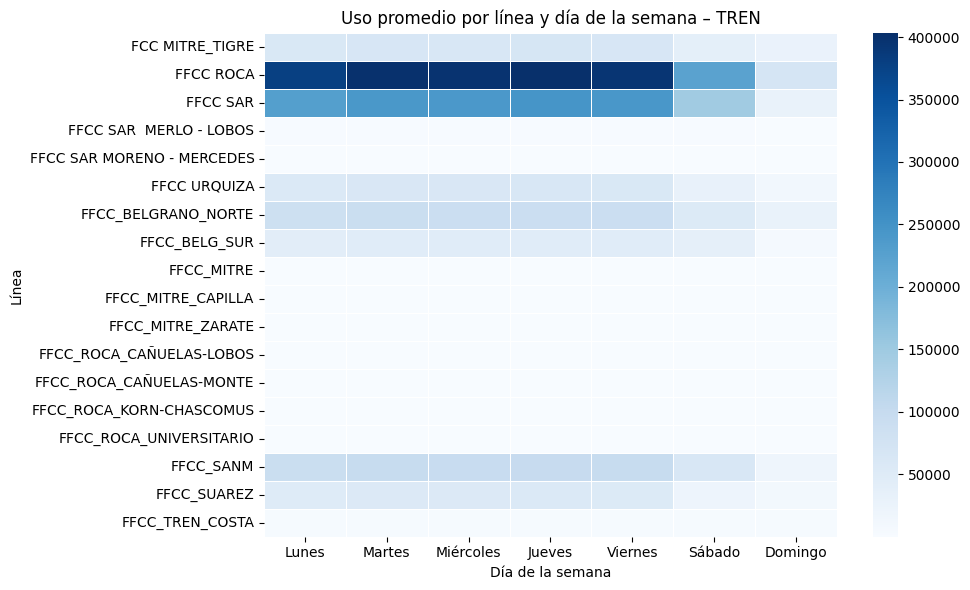

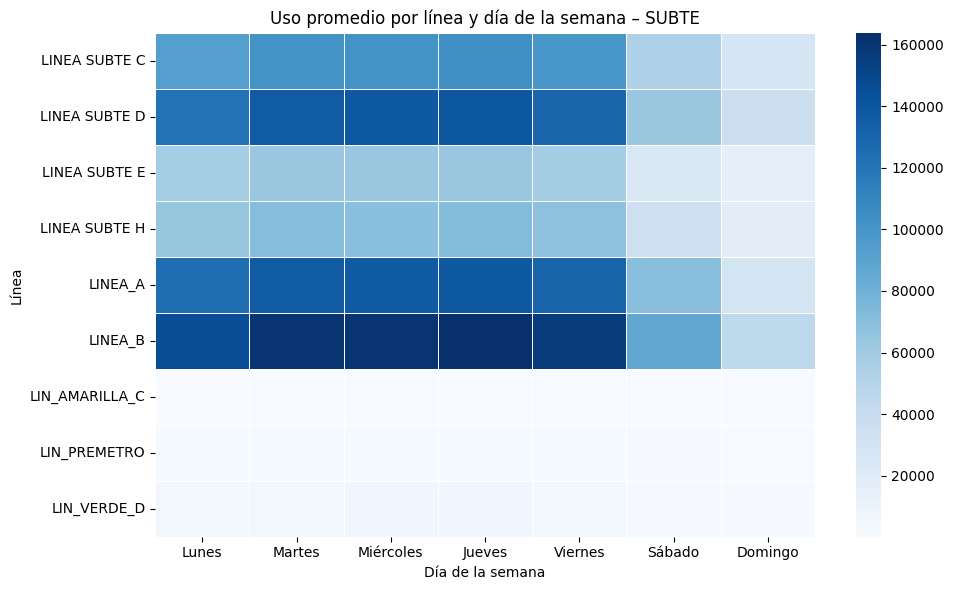

In [29]:
# HEATMAP: USO PROMEDIO POR LÍNEA Y DÍA – TREN vs SUBTE
def heatmap_linea_dia(df, nombre):
    heat_data = (
        df
        .groupby(["LINEA", "dia_semana"])["CANTIDAD"]
        .mean()
        .unstack()
    )

    heat_data.columns = [
        "Lunes", "Martes", "Miércoles",
        "Jueves", "Viernes", "Sábado", "Domingo"
    ]

    plt.figure(figsize=(10,6))
    sns.heatmap(
        heat_data,
        cmap="Blues",
        linewidths=0.5
    )
    plt.title(f"Uso promedio por línea y día de la semana – {nombre}")
    plt.xlabel("Día de la semana")
    plt.ylabel("Línea")
    plt.tight_layout()
    plt.show()

# TREN
heatmap_linea_dia(df_tren, "TREN")

# SUBTE
heatmap_linea_dia(df_subte, "SUBTE")


LINEA,FCC MITRE_TIGRE,FFCC ROCA,FFCC SAR,FFCC SAR MERLO - LOBOS,FFCC SAR MORENO - MERCEDES,FFCC URQUIZA,FFCC_BELGRANO_NORTE,FFCC_BELG_SUR,FFCC_MITRE,FFCC_MITRE_CAPILLA,FFCC_MITRE_ZARATE,FFCC_ROCA_CAÑUELAS-LOBOS,FFCC_ROCA_CAÑUELAS-MONTE,FFCC_ROCA_KORN-CHASCOMUS,FFCC_ROCA_UNIVERSITARIO,FFCC_SANM,FFCC_SUAREZ,FFCC_TREN_COSTA
anio,,,,,,,,,,,,,,,,,,
2023,63259.0,342768.0,189458.0,2880.0,23.0,53274.0,83395.0,43845.0,491.0,NaN,257.0,47.0,47.0,330.0,988.0,82658.0,43932.0,3524.0
2024,60205.0,323061.0,206252.0,2414.0,16.0,48780.0,73355.0,36862.0,180.0,170.0,206.0,46.0,30.0,221.0,628.0,76215.0,46941.0,3465.0
2025,40671.0,305917.0,194335.0,NaN,NaN,48482.0,71949.0,35956.0,160.0,123.0,114.0,34.0,16.0,173.0,562.0,85876.0,39274.0,4041.0


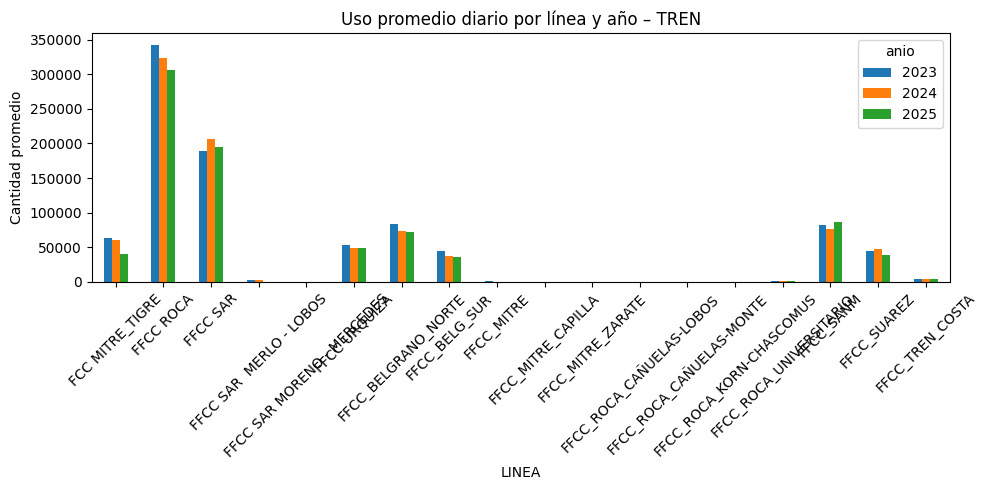

In [ ]:
# Interanual 2023-2024-2025
# USO PROMEDIO POR AÑO Y LÍNEA

uso_anual = (
    df_tren
    .groupby(["anio", "LINEA"])["CANTIDAD"]
    .mean()
    .unstack()
)

display(uso_anual.round(0))

uso_anual.T.plot(kind="bar", figsize=(10,5))
plt.title("Uso promedio diario por línea y año – TREN")
plt.ylabel("Cantidad promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

LINEA,LINEA SUBTE C,LINEA SUBTE D,LINEA SUBTE E,LINEA SUBTE H,LINEA_A,LINEA_B,LIN_AMARILLA_C,LIN_PREMETRO,LIN_VERDE_D
anio,,,,,,,,,
2023,96176.0,146099.0,57190.0,64479.0,132956.0,160060.0,NaN,1399.0,NaN
2024,85635.0,102949.0,54915.0,60960.0,117612.0,137457.0,NaN,1040.0,NaN
2025,65845.0,77158.0,36717.0,44740.0,75682.0,94531.0,397.0,1609.0,4350.0


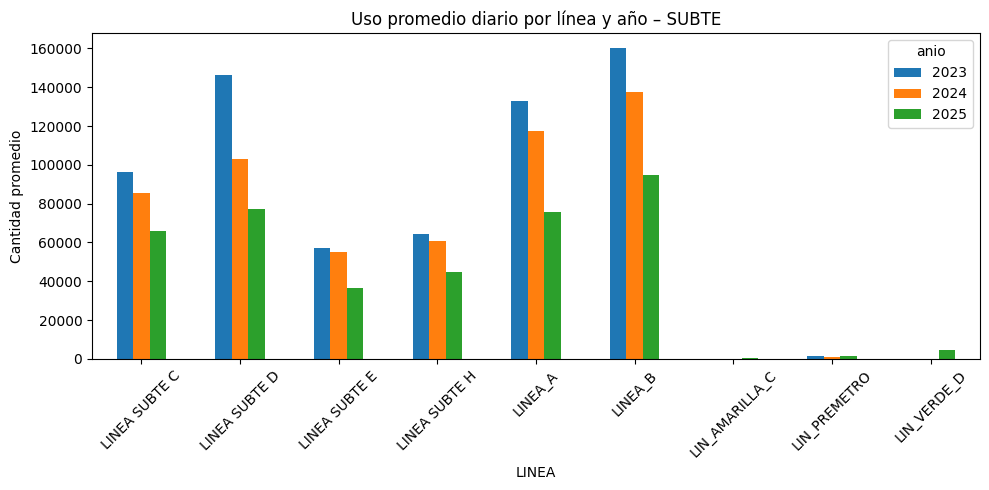

In [30]:
# INTERANUAL 2023–2024–2025
# USO PROMEDIO POR AÑO Y LÍNEA – SUBTE
uso_anual_subte = (
    df_subte
    .groupby(["anio", "LINEA"])["CANTIDAD"]
    .mean()
    .unstack()
)

display(uso_anual_subte.round(0))

uso_anual_subte.T.plot(kind="bar", figsize=(10,5))
plt.title("Uso promedio diario por línea y año – SUBTE")
plt.ylabel("Cantidad promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

OLS VS BAGGING

In [32]:
# TRAIN / TEST SPLIT – TREN y SUBTE

corte = pd.to_datetime("2024-12-31")

def hacer_split_train_test(df, nombre, corte):
    print(f"\n=== Split para {nombre} ===")
    # Split por fecha
    train = df[df["fecha"] < corte].copy()
    test  = df[df["fecha"] >= corte].copy()

    print("Split inicial por fecha:")
    print("Train:", train.shape)
    print("Test :", test.shape)
    return train, test

train_tren, test_tren   = hacer_split_train_test(df_tren,  "TREN",  corte)
train_subte, test_subte = hacer_split_train_test(df_subte, "SUBTE", corte)


=== Split para TREN ===
Split inicial por fecha:
Train: (12237, 21)
Test : (5075, 21)

=== Split para SUBTE ===
Split inicial por fecha:
Train: (5057, 21)
Test : (2502, 21)


In [33]:
# VARIABLES EXPLICATIVAS – TREN y SUBTE
# Variables numéricas y categóricas (comunes a ambos)
numeric_features = [
    "lag_1", "lag_7", "media_7", "media_30",
    "anio", "mes", "dia_mes", "dia_semana", "fin_semana"
]

categorical_features = ["LINEA", "JURISDICCION", "PROVINCIA", "MUNICIPIO"]


def preparar_X_y(train, test, nombre):
    """
    Prepara X_train, y_train, X_test, y_test
    para un medio de transporte.
    """
    X_train = train[numeric_features + categorical_features].copy()
    y_train = train["CANTIDAD"].copy()

    X_test  = test[numeric_features + categorical_features].copy()
    y_test  = test["CANTIDAD"].copy()

    print(f"\nVariables listas para {nombre}:")
    print("X_train:", X_train.shape, "| y_train:", y_train.shape)
    print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

    return X_train, y_train, X_test, y_test


# TREN
X_train_tren, y_train_tren, X_test_tren, y_test_tren = preparar_X_y(
    train_tren, test_tren, "TREN"
)

# SUBTE
X_train_subte, y_train_subte, X_test_subte, y_test_subte = preparar_X_y(
    train_subte, test_subte, "SUBTE"
)


Variables listas para TREN:
X_train: (12237, 13) | y_train: (12237,)
X_test : (5075, 13) | y_test : (5075,)

Variables listas para SUBTE:
X_train: (5057, 13) | y_train: (5057,)
X_test : (2502, 13) | y_test : (2502,)


In [34]:
# PIPELINE: ONE-HOT + BAGGING REGRESSOR PARA TREN Y SUBTE

# Árbol base (se reutiliza la misma especificación)
base_tree = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

# ------------------ TREN ------------------
bagging_tren = BaggingRegressor(
    estimator=base_tree,
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

preprocess_tren = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipe_tren = Pipeline(steps=[
    ("prep", preprocess_tren),
    ("model", bagging_tren)
])

# ------------------ SUBTE ------------------
bagging_subte = BaggingRegressor(
    estimator=base_tree,
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

preprocess_subte = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipe_subte = Pipeline(steps=[
    ("prep", preprocess_subte),
    ("model", bagging_subte)
])


In [35]:
# ENTRENAR MODELO PARA TREN Y SUBTE
for tipo, X_tr, y_tr, X_te, y_te in [
    ("TREN",  X_train_tren,  y_train_tren,  X_test_tren,  y_test_tren),
    ("SUBTE", X_train_subte, y_train_subte, X_test_subte, y_test_subte)
]:
    print(f"\nEntrenando modelo Bagging ({tipo})...")
    pipe.fit(X_tr, y_tr)

    # Predicción en test
    y_pred = pipe.predict(X_te)

    # MÉTRICAS
    mae = mean_absolute_error(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, y_pred)

    print(f"\n===== RESULTADOS BAGGING ({tipo}) =====")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²  : {r2:,.3f}")



Entrenando modelo Bagging (TREN)...

===== RESULTADOS BAGGING (TREN) =====
MAE : 7,242.99
RMSE: 21,327.09
R²  : 0.949

Entrenando modelo Bagging (SUBTE)...

===== RESULTADOS BAGGING (SUBTE) =====
MAE : 7,900.11
RMSE: 13,295.37
R²  : 0.887


In [47]:
# COMPARACION OLS VS BAGGING
# Inicializo variables para guardar resultados de OLS
mae_ols_tren = rmse_ols_tren = r2_ols_tren = None
mae_ols_subte = rmse_ols_subte = r2_ols_subte = None
y_pred_ols_tren = y_pred_ols_subte = None

for tipo, X_train, X_test, y_train, y_test in [
    ("TREN",  X_train_tren,  X_test_tren,  y_train_tren,  y_test_tren),
    ("SUBTE", X_train_subte, X_test_subte, y_train_subte, y_test_subte)
]:

    print(f"\n================ OLS {tipo} ================")

    # OneHot para OLS
    X_train_dum = pd.get_dummies(
        X_train,
        columns=categorical_features,
        drop_first=True
    )

    X_test_dum = pd.get_dummies(
        X_test,
        columns=categorical_features,
        drop_first=True
    )

    # y como float
    y_train_ols = y_train.astype(float)
    y_test_ols  = y_test.astype(float)

    # Limpiar NaN SOLO en train
    df_train = pd.concat(
        [y_train_ols.rename("CANTIDAD"), X_train_dum],
        axis=1
    ).dropna()

    y_train_ols = df_train["CANTIDAD"]
    X_train_ols = df_train.drop(columns="CANTIDAD")

    # Alinear test con train
    X_test_ols = X_test_dum.reindex(
        columns=X_train_ols.columns,
        fill_value=0
    )

    # A float
    X_train_ols = X_train_ols.astype(float)
    X_test_ols  = X_test_ols.astype(float)

    # Constante
    X_train_ols = sm.add_constant(X_train_ols)
    X_test_ols  = sm.add_constant(X_test_ols)

    # Ajustar modelo
    ols_model = sm.OLS(y_train_ols, X_train_ols).fit()
    print(ols_model.summary())

    # Predicción
    y_pred_ols = ols_model.predict(X_test_ols)

    # Quitar NaN en test para métricas
    mask = (~y_test_ols.isna()) & (~pd.isna(y_pred_ols))
    y_test_valid = y_test_ols[mask]
    y_pred_valid = y_pred_ols[mask]

    # Métricas OLS
    mae_ols  = mean_absolute_error(y_test_valid, y_pred_valid)
    rmse_ols = np.sqrt(mean_squared_error(y_test_valid, y_pred_valid))
    r2_ols   = r2_score(y_test_valid, y_pred_valid)

    print(f"\nMÉTRICAS OLS ({tipo})")
    print(f"MAE : {mae_ols:,.2f}")
    print(f"RMSE: {rmse_ols:,.2f}")
    print(f"R²  : {r2_ols:,.3f}")

    # Guardar resultados de OLS por tipo
    if tipo == "TREN":
        mae_ols_tren = mae_ols
        rmse_ols_tren = rmse_ols
        r2_ols_tren = r2_ols
        y_pred_ols_tren = y_pred_ols
    else:  # SUBTE
        mae_ols_subte = mae_ols
        rmse_ols_subte = rmse_ols
        r2_ols_subte = r2_ols
        y_pred_ols_subte = y_pred_ols


================ OLS TREN ================
                            OLS Regression Results                            
Dep. Variable:               CANTIDAD   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     4813.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        02:46:48   Log-Likelihood:            -1.4179e+05
No. Observations:               12129   AIC:                         2.836e+05
Df Residuals:                   12102   BIC:                         2.838e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------


=== COMPARACIÓN OLS vs BAGGING – TREN ===
Modelo		MAE		RMSE		R2
OLS   	12,691.92	28,454.01	0.909
Bagging	7,900.11	13,295.37	0.887


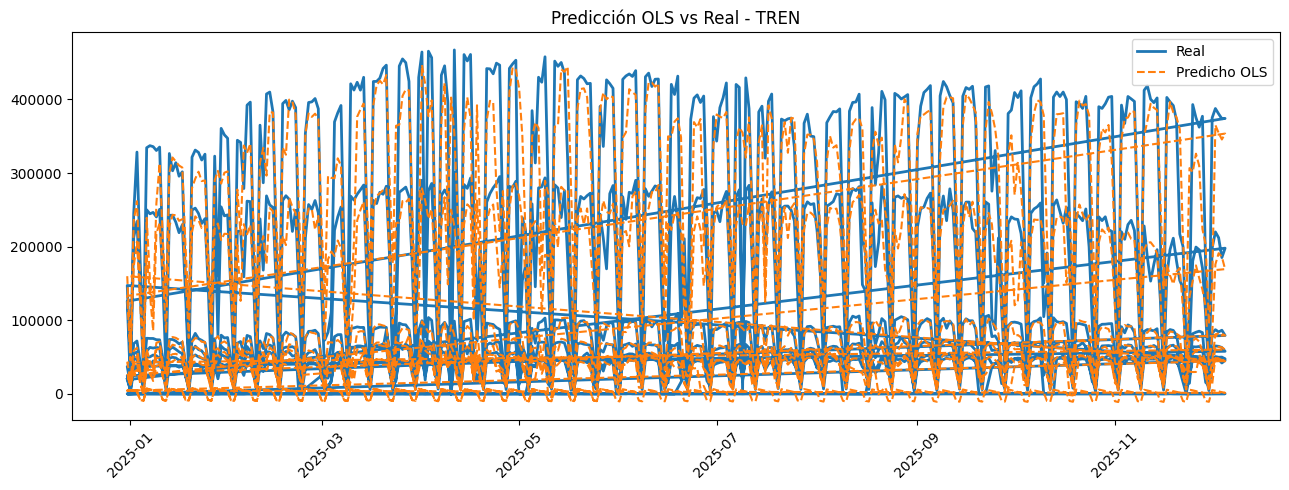

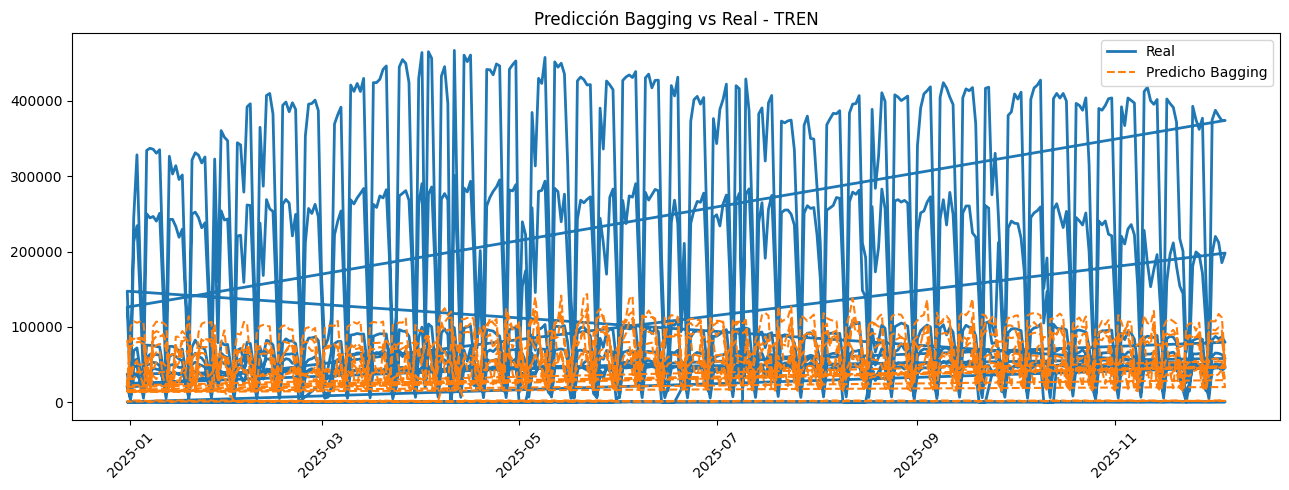


=== COMPARACIÓN OLS vs BAGGING – SUBTE ===
Modelo		MAE		RMSE		R2
OLS   	11,013.49	16,080.78	0.834
Bagging	7,900.11	13,295.37	0.887


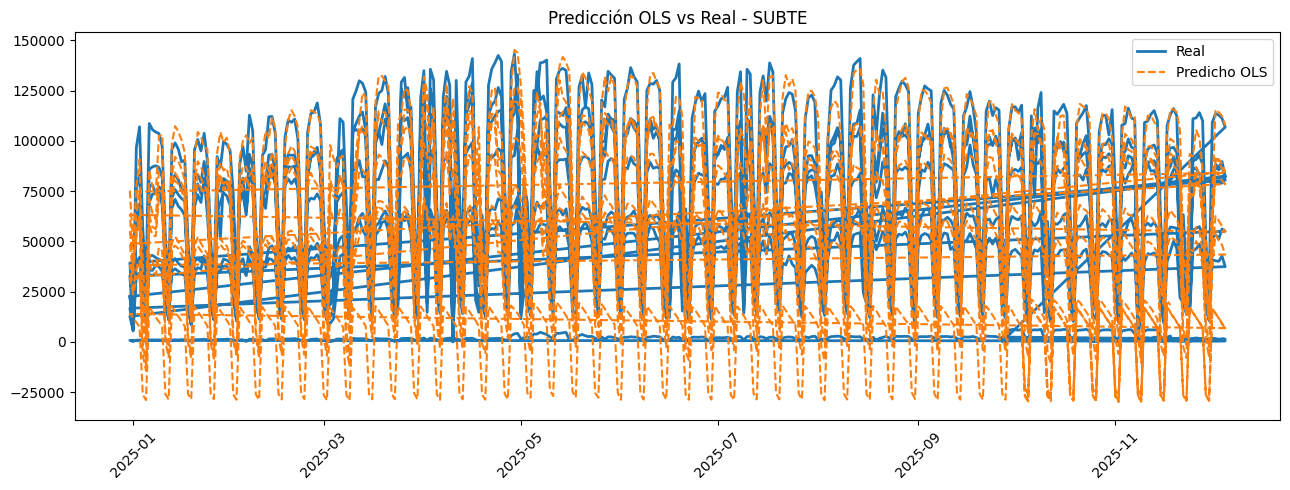

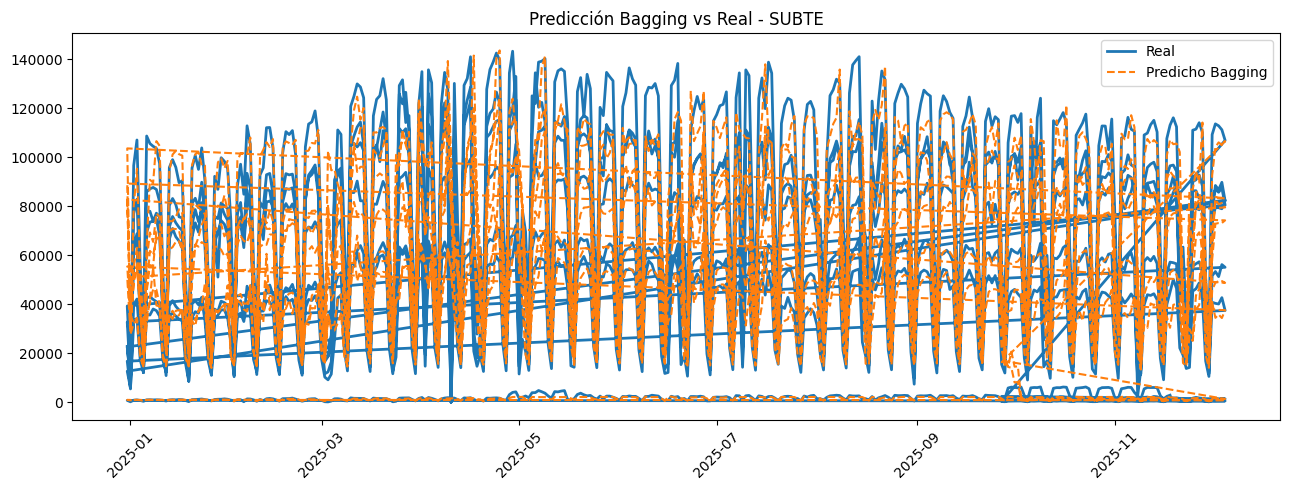

In [49]:
# TABLA COMPARATIVA Y GRÁFICOS – TREN Y SUBTE

print("\n=== COMPARACIÓN OLS vs BAGGING – TREN ===")
print(f"Modelo\t\tMAE\t\tRMSE\t\tR2")
print(f"OLS   \t{mae_ols_tren:,.2f}\t{rmse_ols_tren:,.2f}\t{r2_ols_tren:,.3f}")
print(f"Bagging\t{mae_tren:,.2f}\t{rmse_tren:,.2f}\t{r2_tren:,.3f}")

# Alinear longitudes para TREN
n_tren = min(len(y_test_tren), len(y_pred_tren))
fechas_tren      = test_tren["fecha"].iloc[:n_tren]
y_test_tren_plot = y_test_tren.iloc[:n_tren]
y_pred_tren_plot = y_pred_tren[:n_tren]

plt.figure(figsize=(13,5))
plt.plot(fechas_tren, y_test_tren_plot.values, label="Real", linewidth=2)
plt.plot(fechas_tren, y_pred_ols_tren[:n_tren], label="Predicho OLS", linestyle="--")
plt.title("Predicción OLS vs Real - TREN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(13,5))
plt.plot(fechas_tren, y_test_tren_plot.values, label="Real", linewidth=2)
plt.plot(fechas_tren, y_pred_tren_plot, label="Predicho Bagging", linestyle="--")
plt.title("Predicción Bagging vs Real - TREN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


print("\n=== COMPARACIÓN OLS vs BAGGING – SUBTE ===")
print(f"Modelo\t\tMAE\t\tRMSE\t\tR2")
print(f"OLS   \t{mae_ols_subte:,.2f}\t{rmse_ols_subte:,.2f}\t{r2_ols_subte:,.3f}")
print(f"Bagging\t{mae_subte:,.2f}\t{rmse_subte:,.2f}\t{r2_subte:,.3f}")

# Alinear longitudes para SUBTE
n_sub = min(len(y_test_subte), len(y_pred_subte))
fechas_sub      = test_subte["fecha"].iloc[:n_sub]
y_test_sub_plot = y_test_subte.iloc[:n_sub]
y_pred_sub_plot = y_pred_subte[:n_sub]

plt.figure(figsize=(13,5))
plt.plot(fechas_sub, y_test_sub_plot.values, label="Real", linewidth=2)
plt.plot(fechas_sub, y_pred_ols_subte[:n_sub], label="Predicho OLS", linestyle="--")
plt.title("Predicción OLS vs Real - SUBTE")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(13,5))
plt.plot(fechas_sub, y_test_sub_plot.values, label="Real", linewidth=2)
plt.plot(fechas_sub, y_pred_sub_plot, label="Predicho Bagging", linestyle="--")
plt.title("Predicción Bagging vs Real - SUBTE")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

